In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
ls

explore-gtdb-vs-mags.ipynb  explore-manysearch.ipynb


In [3]:
ls ../outputs.cds3

INCOMPLETE.gtdb.cds3.x.3216.manysearch.csv
gtdb.cds3.x.3216.manysearch.csv
mag+gtdb.cds.sig.zip
mag+gtdb.cds.singleton.describe.csv
mag+gtdb.cds.singleton.sig.d/
mag+gtdb.cds.singleton.sig.zip
mag+gtdb.cds3.x.3216.manysearch.csv
mag+gtdb.cds3.x.3216.manysearch.csv.2700
mag+gtdb.cds3.x.3216.manysearch.csv.3216.csv@
mag-cds.sig.zip
mag-manysketch.csv
pq/
prodigal/


In [4]:
mag_gtdb_df = (
    pl.read_csv('../outputs.cds3/mag+gtdb.cds.singleton.describe.csv')
    .select(['name', 'n_hashes', 'sum_hashes'])
    .rename({ "n_hashes": "mags_n_hashes", "sum_hashes": "mags_sum_hashes" })

)


In [5]:
mag_gtdb_df

name,mags_n_hashes,mags_sum_hashes
str,i64,i64
"""GCA_903856435 s__PALSA-747 sp9…",927,927
"""GCA_038131005 s__Kariarchaeum …",1891,1891
"""GCA_027329665 s__JAJZVQ01 sp02…",941,941
"""GCA_038044745 s__JBBSZK01 sp03…",527,527
"""GCA_963606895 s__Methanocatell…",2518,2518
…,…,…
"""GCA_902774455 s__Cryptobactero…",812,812
"""GCA_034437595 s__40CM-4-65-16 …",1038,1038
"""GCA_018262985 s__JAFGNN01 sp01…",783,783


In [17]:
gtdb_df = (
    pl.read_csv('/home/ctbrown/scratch3/2026-gtdb-dl/gtdb-cds-rs226.species.singleton.describe.csv')
    .select(['name', 'n_hashes', 'sum_hashes'])
    .rename({ "n_hashes": "gtdb_n_hashes", "sum_hashes": "gtdb_sum_hashes" })
)
gtdb_df

name,gtdb_n_hashes,gtdb_sum_hashes
str,i64,i64
"""GCA_903856435 s__PALSA-747 sp9…",927,927
"""GCA_038131005 s__Kariarchaeum …",1893,1893
"""GCA_027329665 s__JAJZVQ01 sp02…",942,942
"""GCA_038044745 s__JBBSZK01 sp03…",527,527
"""GCA_963606895 s__Methanocatell…",2289,2289
…,…,…
"""GCA_902774455 s__Cryptobactero…",813,813
"""GCA_034437595 s__40CM-4-65-16 …",1039,1039
"""GCA_018262985 s__JAFGNN01 sp01…",783,783


In [7]:
combo_df = (
    gtdb_df.join(mag_gtdb_df, on='name', how='inner')
    .with_columns(diff_n_hashes=pl.col('mags_n_hashes') - pl.col('gtdb_n_hashes'),
                  diff_sum_hashes=pl.col('mags_sum_hashes') - pl.col('gtdb_sum_hashes'),
                 )
    .sort('diff_sum_hashes', descending=True)
)
combo_df

name,gtdb_n_hashes,gtdb_sum_hashes,mags_n_hashes,mags_sum_hashes,diff_n_hashes,diff_sum_hashes
str,i64,i64,i64,i64,i64,i64
"""GCA_946007015 s__UBA2868 sp004…",2805,2805,7261,7261,4456,4456
"""GCA_945501735 s__Prevotella sp…",4473,4473,6308,6308,1835,1835
"""GCA_945834365 s__Sodaliphilus …",10232,10232,11948,11948,1716,1716
"""GCA_012515615 s__JAAYIG01 sp01…",3018,3018,4690,4690,1672,1672
"""GCA_034104265 s__UBA11524 sp03…",995,995,2655,2655,1660,1660
…,…,…,…,…,…,…
"""GCF_020561685 s__Dorea formici…",5523,5523,5339,5339,-184,-184
"""GCA_958418755 s__Blautia_A wex…",9033,9033,8846,8846,-187,-187
"""GCA_022764085 s__Prevotella sp…",2141,2141,1908,1908,-233,-233


## Compare manysearch output

In [8]:
mags_df = (
    pl.scan_parquet('../outputs.cds3/pq/mag+gtdb.cds3.x.3216.manysearch.parquet')
    .filter(pl.col('intersect_hashes') >= 20)
).collect()

In [9]:
gtdb_df = (
    pl.scan_parquet('../outputs.cds3/pq/INCOMPLETE.gtdb.cds3.x.3216.manysearch.parquet')
    .filter(pl.col('intersect_hashes') >= 20)
).collect()

In [10]:
mags_df = mags_df.with_columns(
    f_weighted=pl.col('n_weighted_found') / pl.col('total_weighted_hashes')
)
gtdb_df = gtdb_df.with_columns(
    f_weighted=pl.col('n_weighted_found') / pl.col('total_weighted_hashes')
)

In [11]:
gtdb_species_df = gtdb_df.group_by('query_name').agg(
    sum_weighted_gtdb=(pl.col('total_weighted_hashes')*pl.col('scaled')).sum()
)

In [12]:
mags_species_df = mags_df.group_by('query_name').agg(
    sum_weighted_mags=(pl.col('total_weighted_hashes')*pl.col('scaled')).sum()
)

In [13]:
OLD_NAMES = [ x.strip() for x in open('../../2025-workflow-core99/inputs.cds/names.list') ]

In [15]:
combo_df = gtdb_species_df.join(mags_species_df, on='query_name', how='inner').with_columns(
    diff=pl.col('sum_weighted_mags') - pl.col('sum_weighted_gtdb'),
    species_name=pl.col('query_name').str.split(' ').list.slice(1, 2).list.join( " ")
).drop('query_name').sort('diff', descending=True)

with pl.Config(tbl_rows=-1):
    print(combo_df.filter(pl.col('species_name').is_in(OLD_NAMES)))

shape: (16, 4)
┌───────────────────┬───────────────────┬───────────────┬─────────────────────────────────┐
│ sum_weighted_gtdb ┆ sum_weighted_mags ┆ diff          ┆ species_name                    │
│ ---               ┆ ---               ┆ ---           ┆ ---                             │
│ i64               ┆ i64               ┆ i64           ┆ str                             │
╞═══════════════════╪═══════════════════╪═══════════════╪═════════════════════════════════╡
│ 10817837237000    ┆ 13894140619000    ┆ 3076303382000 ┆ s__UBA2868 sp004552595          │
│ 11109031524000    ┆ 13821912584000    ┆ 2712881060000 ┆ s__JAFBIX01 sp021531895         │
│ 11256870681000    ┆ 13834699186000    ┆ 2577828505000 ┆ s__Mogibacterium_A kristiansen… │
│ 11461377674000    ┆ 13768310726000    ┆ 2306933052000 ┆ s__Floccifex porci              │
│ 11685204523000    ┆ 13877750989000    ┆ 2192546466000 ┆ s__Bariatricus sp004560705      │
│ 11973527907000    ┆ 14068009169000    ┆ 2094481262000 ┆ s__Lact

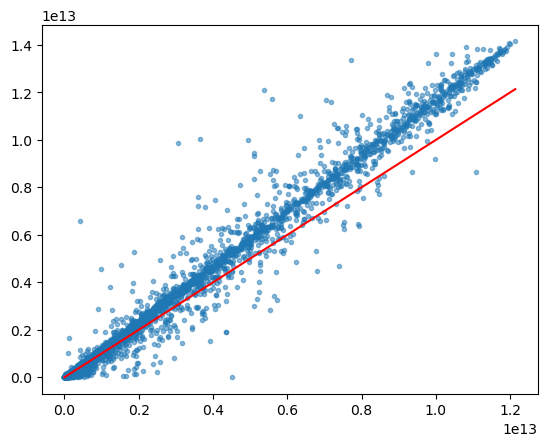

In [16]:
plt.plot(combo_df['sum_weighted_gtdb'], combo_df['sum_weighted_mags'], '.', alpha=0.5)
plt.plot([0, max(combo_df['sum_weighted_gtdb'])], [0, max(combo_df['sum_weighted_gtdb'])],
        'r-')

In [19]:
"%g" % (combo_df['diff'].sum(),)

'1.77937e+15'

In [22]:
"%g" % (combo_df['sum_weighted_mags'].sum(),)

'1.33967e+16'

In [20]:
"%g" % (combo_df['sum_weighted_gtdb'].sum(),)

'1.16173e+16'

In [21]:
combo_df['diff'].sum() / combo_df['sum_weighted_gtdb'].sum()

0.1531652638466944